<a href="https://colab.research.google.com/github/Wizako-01/HPV-Colposcopy-model/blob/main/HPV_Colposcopy_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

root = "/content/drive/MyDrive/HPV dataset"

print(os.listdir(root))

['.DS_Store', '02_Abnormal', '01_Normal']


In [ ]:
import os
import pandas as pd

root = "/content/drive/MyDrive/HPV dataset"

rows = []

class_map = {
    "01_Normal": 0,
    "02_Abnormal": 1
}

for class_name, label in class_map.items():
    class_path = os.path.join(root, class_name)

    for patient in os.listdir(class_path):
        patient_path = os.path.join(class_path, patient)

        # skip non-folders like .DS_Store
        if not os.path.isdir(patient_path):
            continue

        for img in os.listdir(patient_path):
            if not img.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            rows.append({
                "image_path": os.path.join(patient_path, img),
                "patient_id": patient,
                "label": label,
                "filename": img
            })

df = pd.DataFrame(rows)

print("Total images:", len(df))
print("Total patients:", df["patient_id"].nunique())
print(df.head())

Total images: 3356
Total patients: 332
                                          image_path patient_id  label  \
0  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_343      0   
1  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_343      0   
2  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_343      0   
3  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_343      0   
4  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_343      0   

   filename  
0  po3b.jpg  
1   p4b.jpg  
2   po4.jpg  
3    p2.jpg  
4  po4b.jpg  


In [ ]:
import random

def patient_split(df, seed=42):
    random.seed(seed)

    # get unique patients
    patients = df[["patient_id", "label"]].drop_duplicates()

    normal = patients[patients["label"] == 0]["patient_id"].tolist()
    abnormal = patients[patients["label"] == 1]["patient_id"].tolist()

    random.shuffle(normal)
    random.shuffle(abnormal)

    def split(lst):
        n = len(lst)
        train = lst[:int(0.7*n)]
        val = lst[int(0.7*n):int(0.85*n)]
        test = lst[int(0.85*n):]
        return train, val, test

    n_train, n_val, n_test = split(normal)
    a_train, a_val, a_test = split(abnormal)

    train_ids = set(n_train + a_train)
    val_ids = set(n_val + a_val)
    test_ids = set(n_test + a_test)

    train_df = df[df["patient_id"].isin(train_ids)]
    val_df = df[df["patient_id"].isin(val_ids)]
    test_df = df[df["patient_id"].isin(test_ids)]

    return train_df, val_df, test_df


train_df, val_df, test_df = patient_split(df)

print("Train patients:", train_df["patient_id"].nunique())
print("Val patients:", val_df["patient_id"].nunique())
print("Test patients:", test_df["patient_id"].nunique())

Train patients: 232
Val patients: 49
Test patients: 51


In [ ]:
print(
    set(train_df.patient_id) & set(val_df.patient_id),
    set(train_df.patient_id) & set(test_df.patient_id),
    set(val_df.patient_id) & set(test_df.patient_id)
)

set() set() set()


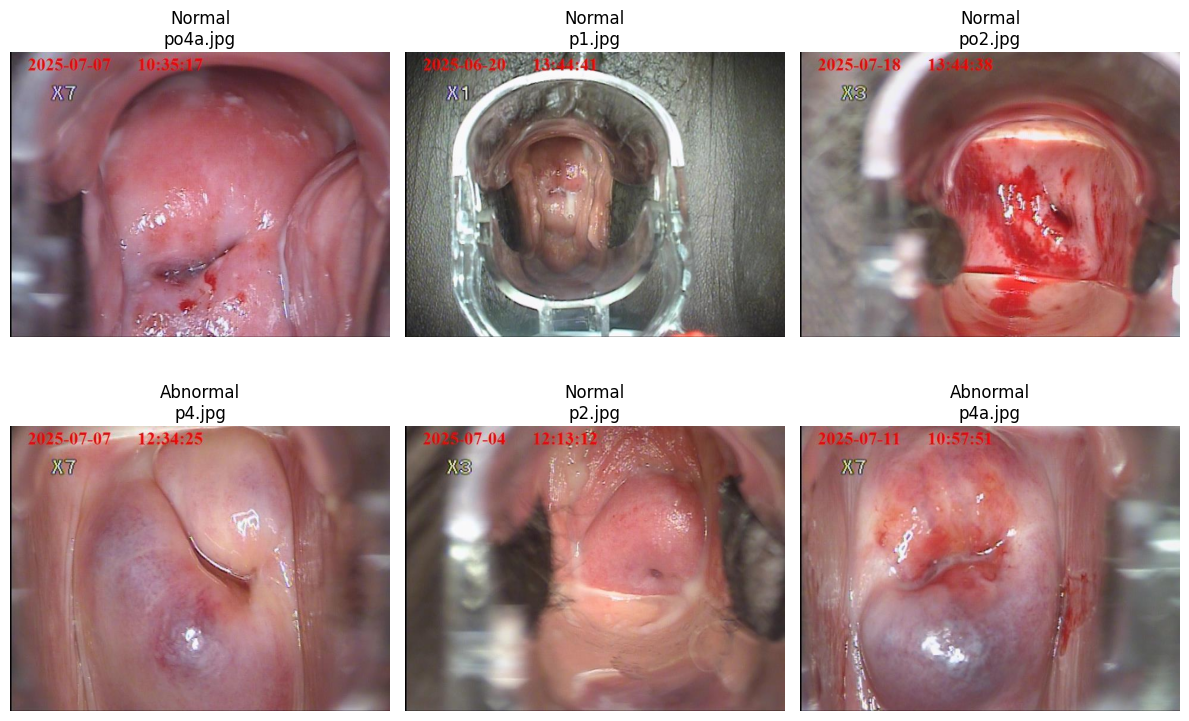

In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image

def show_random_images(df, n=6):
    samples = df.sample(n)

    plt.figure(figsize=(12, 8))

    for i, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row["image_path"])

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.axis("off")

        label = "Normal" if row["label"] == 0 else "Abnormal"
        plt.title(f"{label}\n{row['filename']}")

    plt.tight_layout()
    plt.show()

show_random_images(df, 6)

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class ColposcopyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")
        label = row["label"]

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
train_dataset = ColposcopyDataset(train_df, transform=train_transform)
val_dataset = ColposcopyDataset(val_df, transform=val_transform)
test_dataset = ColposcopyDataset(test_df, transform=val_transform)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([16, 3, 224, 224]) torch.Size([16])


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# model
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 1)
model = model.to(device)

# loss + optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# test forward pass
images, labels = next(iter(train_loader))
images = images.to(device)

outputs = model(images)
print("Output shape:", outputs.shape)

Using device: cuda
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 185MB/s]


Output shape: torch.Size([16, 1])


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(outputs).detach().cpu().numpy().ravel()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    preds = [1 if p >= 0.5 else 0 for p in all_probs]
    acc = accuracy_score(all_labels, preds)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = np.nan

    return epoch_loss, acc, auc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs).cpu().numpy().ravel()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    preds = [1 if p >= 0.5 else 0 for p in all_probs]
    acc = accuracy_score(all_labels, preds)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = np.nan

    return epoch_loss, acc, auc


num_epochs = 5
best_val_auc = -1
best_model_path = "/content/best_baseline_densenet121.pth"

for epoch in range(num_epochs):
    train_loss, train_acc, train_auc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_auc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train AUC: {train_auc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   AUC: {val_auc:.4f}")
    print("-" * 60)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), best_model_path)

print("Best model saved to:", best_model_path)

KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import StratifiedKFold

# one row per patient
patient_df = df[["patient_id", "label"]].drop_duplicates().reset_index(drop=True)

print("Total patients:", len(patient_df))
print(patient_df["label"].value_counts())
patient_df.head()

Total patients: 332
label
0    210
1    122
Name: count, dtype: int64


,patient_id,label
0,buth_343,0
1,buth_341,0
2,buth_339,0
3,buth_338,0
4,buth_336,0


In [ ]:
from sklearn.model_selection import StratifiedKFold

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_data = []

X = patient_df["patient_id"].values
y = patient_df["label"].values

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    train_patients = patient_df.iloc[train_idx]["patient_id"].tolist()
    val_patients = patient_df.iloc[val_idx]["patient_id"].tolist()

    train_fold_df = df[df["patient_id"].isin(train_patients)].reset_index(drop=True)
    val_fold_df = df[df["patient_id"].isin(val_patients)].reset_index(drop=True)

    fold_data.append({
        "fold": fold,
        "train_patients": train_patients,
        "val_patients": val_patients,
        "train_df": train_fold_df,
        "val_df": val_fold_df
    })

    print(f"Fold {fold}")
    print("  Train patients:", len(train_patients), "| Images:", len(train_fold_df))
    print("  Val patients:  ", len(val_patients), "| Images:", len(val_fold_df))
    print("  Train class counts:\n", train_fold_df['label'].value_counts().sort_index().to_dict())
    print("  Val class counts:  \n", val_fold_df['label'].value_counts().sort_index().to_dict())
    print("-" * 50)

Fold 1
  Train patients: 265 | Images: 2681
  Val patients:   67 | Images: 675
  Train class counts:
 {0: 1703, 1: 978}
  Val class counts:  
 {0: 431, 1: 244}
--------------------------------------------------
Fold 2
  Train patients: 265 | Images: 2672
  Val patients:   67 | Images: 684
  Train class counts:
 {0: 1714, 1: 958}
  Val class counts:  
 {0: 420, 1: 264}
--------------------------------------------------
Fold 3
  Train patients: 266 | Images: 2663
  Val patients:   66 | Images: 693
  Train class counts:
 {0: 1692, 1: 971}
  Val class counts:  
 {0: 442, 1: 251}
--------------------------------------------------
Fold 4
  Train patients: 266 | Images: 2694
  Val patients:   66 | Images: 662
  Train class counts:
 {0: 1708, 1: 986}
  Val class counts:  
 {0: 426, 1: 236}
--------------------------------------------------
Fold 5
  Train patients: 266 | Images: 2714
  Val patients:   66 | Images: 642
  Train class counts:
 {0: 1719, 1: 995}
  Val class counts:  
 {0: 415, 1: 2

In [ ]:
for item in fold_data:
    fold = item["fold"]
    train_ids = set(item["train_df"]["patient_id"].unique())
    val_ids = set(item["val_df"]["patient_id"].unique())

    overlap = train_ids & val_ids
    print(f"Fold {fold} overlap:", overlap)

Fold 1 overlap: set()
Fold 2 overlap: set()
Fold 3 overlap: set()
Fold 4 overlap: set()
Fold 5 overlap: set()


In [ ]:
fold1_train_df = fold_data[0]["train_df"]
fold1_val_df = fold_data[0]["val_df"]

print(fold1_train_df.head())
print(fold1_val_df.head())

                                          image_path patient_id  label  \
0  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_341      0   
1  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_341      0   
2  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_341      0   
3  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_341      0   
4  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_341      0   

  filename  
0  po1.jpg  
1   p2.jpg  
2  po2.jpg  
3   p1.jpg  
4  po4.jpg  
                                          image_path patient_id  label  \
0  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_343      0   
1  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_343      0   
2  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_343      0   
3  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_343      0   
4  /content/drive/MyDrive/HPV dataset/01_Normal/b...   buth_343      0   

   filename  
0  po3b.jpg  
1   

In [ ]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score

# -----------------------------
# 1. CONFIG
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BATCH_SIZE = 16
NUM_EPOCHS = 5
LR = 1e-4
N_SPLITS = 5
SEED = 42

# -----------------------------
# 2. DATASET
# -----------------------------
class ColposcopyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        label = row["label"]
        patient_id = row["patient_id"]

        if self.transform:
            img = self.transform(img)

        return img, label, patient_id

# -----------------------------
# 3. TRANSFORMS
# -----------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# -----------------------------
# 4. MODEL
# -----------------------------
def get_model():
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, 1)
    return model.to(device)

# -----------------------------
# 5. TRAIN / EVAL FUNCTIONS
# -----------------------------
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(outputs).detach().cpu().numpy().ravel()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    preds = (np.array(all_probs) >= 0.5).astype(int)
    acc = accuracy_score(all_labels, preds)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = np.nan

    return epoch_loss, acc, auc

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []
    all_patient_ids = []

    with torch.no_grad():
        for images, labels, patient_ids in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs).cpu().numpy().ravel()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy().ravel())
            all_patient_ids.extend(patient_ids)

    epoch_loss = running_loss / len(loader.dataset)

    # image-level
    image_preds = (np.array(all_probs) >= 0.5).astype(int)
    image_acc = accuracy_score(all_labels, image_preds)
    try:
        image_auc = roc_auc_score(all_labels, all_probs)
    except:
        image_auc = np.nan

    # patient-level
    results_df = pd.DataFrame({
        "patient_id": all_patient_ids,
        "label": all_labels,
        "prob": all_probs
    })

    patient_df_eval = (
        results_df.groupby("patient_id")
        .agg(label=("label", "first"), prob=("prob", "mean"))
        .reset_index()
    )
    patient_df_eval["pred"] = (patient_df_eval["prob"] >= 0.5).astype(int)

    patient_acc = accuracy_score(patient_df_eval["label"], patient_df_eval["pred"])
    try:
        patient_auc = roc_auc_score(patient_df_eval["label"], patient_df_eval["prob"])
    except:
        patient_auc = np.nan

    return {
        "loss": epoch_loss,
        "image_acc": image_acc,
        "image_auc": image_auc,
        "patient_acc": patient_acc,
        "patient_auc": patient_auc,
        "patient_results": patient_df_eval,
        "image_results": results_df
    }

# -----------------------------
# 6. 5-FOLD SETUP
# -----------------------------
patient_df = df[["patient_id", "label"]].drop_duplicates().reset_index(drop=True)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_summaries = []

X = patient_df["patient_id"].values
y = patient_df["label"].values

# -----------------------------
# 7. CROSS-VALIDATION LOOP
# -----------------------------
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n{'='*25} FOLD {fold}/{N_SPLITS} {'='*25}")

    train_patients = patient_df.iloc[train_idx]["patient_id"].tolist()
    val_patients = patient_df.iloc[val_idx]["patient_id"].tolist()

    train_fold_df = df[df["patient_id"].isin(train_patients)].reset_index(drop=True)
    val_fold_df = df[df["patient_id"].isin(val_patients)].reset_index(drop=True)

    print("Train patients:", len(train_patients), "| Train images:", len(train_fold_df))
    print("Val patients:  ", len(val_patients), "| Val images:  ", len(val_fold_df))

    train_dataset = ColposcopyDataset(train_fold_df, transform=train_transform)
    val_dataset = ColposcopyDataset(val_fold_df, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = get_model()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    best_val_auc = -1
    best_state = None

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc, train_auc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics = evaluate(model, val_loader, criterion)

        print(
            f"Epoch {epoch+1}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train AUC: {train_auc:.4f} || "
            f"Val Img Acc: {val_metrics['image_acc']:.4f} | Val Img AUC: {val_metrics['image_auc']:.4f} || "
            f"Val Pt Acc: {val_metrics['patient_acc']:.4f} | Val Pt AUC: {val_metrics['patient_auc']:.4f}"
        )

        if val_metrics["patient_auc"] > best_val_auc:
            best_val_auc = val_metrics["patient_auc"]
            best_state = copy.deepcopy(model.state_dict())

    # final best evaluation
    model.load_state_dict(best_state)
    final_val_metrics = evaluate(model, val_loader, criterion)

    fold_summary = {
        "fold": fold,
        "image_acc": final_val_metrics["image_acc"],
        "image_auc": final_val_metrics["image_auc"],
        "patient_acc": final_val_metrics["patient_acc"],
        "patient_auc": final_val_metrics["patient_auc"],
    }
    fold_summaries.append(fold_summary)

    print(f"\nBest Fold {fold} Results")
    print(f"Image-level  Acc: {fold_summary['image_acc']:.4f} | AUC: {fold_summary['image_auc']:.4f}")
    print(f"Patient-level Acc: {fold_summary['patient_acc']:.4f} | AUC: {fold_summary['patient_auc']:.4f}")

# -----------------------------
# 8. SUMMARY
# -----------------------------
results_df = pd.DataFrame(fold_summaries)
print("\n" + "="*60)
print("5-FOLD CROSS-VALIDATION SUMMARY")
print(results_df)

for metric in ["image_acc", "image_auc", "patient_acc", "patient_auc"]:
    mean_val = results_df[metric].mean()
    std_val = results_df[metric].std()
    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

Using device: cuda

========================= FOLD 1/5 =========================
Train patients: 265 | Train images: 2681
Val patients:   67 | Val images:   675
Epoch 1/5 | Train Loss: 0.6090 | Train Acc: 0.6755 | Train AUC: 0.6737 || Val Img Acc: 0.5837 | Val Img AUC: 0.5380 || Val Pt Acc: 0.5821 | Val Pt AUC: 0.5610
Epoch 2/5 | Train Loss: 0.4332 | Train Acc: 0.7926 | Train AUC: 0.8672 || Val Img Acc: 0.5556 | Val Img AUC: 0.5314 || Val Pt Acc: 0.5672 | Val Pt AUC: 0.5467
Epoch 3/5 | Train Loss: 0.2983 | Train Acc: 0.8706 | Train AUC: 0.9413 || Val Img Acc: 0.6519 | Val Img AUC: 0.5809 || Val Pt Acc: 0.6567 | Val Pt AUC: 0.6238
Epoch 4/5 | Train Loss: 0.2076 | Train Acc: 0.9202 | Train AUC: 0.9720 || Val Img Acc: 0.6148 | Val Img AUC: 0.5487 || Val Pt Acc: 0.6119 | Val Pt AUC: 0.5838
Epoch 5/5 | Train Loss: 0.1747 | Train Acc: 0.9377 | Train AUC: 0.9799 || Val Img Acc: 0.6044 | Val Img AUC: 0.5508 || Val Pt Acc: 0.6269 | Val Pt AUC: 0.5648

Best Fold 1 Results
Image-level  Acc: 0.651

In [ ]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score

# -----------------------------
# 1. CONFIG
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BATCH_SIZE = 16
NUM_EPOCHS = 5
LR = 1e-4
N_SPLITS = 5
SEED = 42

# -----------------------------
# 2. POST-ONLY DATAFRAME
# -----------------------------
post_df = df[df["filename"].str.startswith("po")].reset_index(drop=True)

print("Total post-only images:", len(post_df))
print("Total patients:", post_df["patient_id"].nunique())
print(post_df["label"].value_counts())

# -----------------------------
# 3. DATASET
# -----------------------------
class ColposcopyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        label = row["label"]
        patient_id = row["patient_id"]

        if self.transform:
            img = self.transform(img)

        return img, label, patient_id

# -----------------------------
# 4. TRANSFORMS
# -----------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# -----------------------------
# 5. MODEL
# -----------------------------
def get_model():
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, 1)
    return model.to(device)

# -----------------------------
# 6. TRAIN / EVAL FUNCTIONS
# -----------------------------
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(outputs).detach().cpu().numpy().ravel()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    preds = (np.array(all_probs) >= 0.5).astype(int)
    acc = accuracy_score(all_labels, preds)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = np.nan

    return epoch_loss, acc, auc

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []
    all_patient_ids = []

    with torch.no_grad():
        for images, labels, patient_ids in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs).cpu().numpy().ravel()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy().ravel())
            all_patient_ids.extend(patient_ids)

    epoch_loss = running_loss / len(loader.dataset)

    # image-level
    image_preds = (np.array(all_probs) >= 0.5).astype(int)
    image_acc = accuracy_score(all_labels, image_preds)
    try:
        image_auc = roc_auc_score(all_labels, all_probs)
    except:
        image_auc = np.nan

    # patient-level
    results_df = pd.DataFrame({
        "patient_id": all_patient_ids,
        "label": all_labels,
        "prob": all_probs
    })

    patient_df_eval = (
        results_df.groupby("patient_id")
        .agg(label=("label", "first"), prob=("prob", "mean"))
        .reset_index()
    )
    patient_df_eval["pred"] = (patient_df_eval["prob"] >= 0.5).astype(int)

    patient_acc = accuracy_score(patient_df_eval["label"], patient_df_eval["pred"])
    try:
        patient_auc = roc_auc_score(patient_df_eval["label"], patient_df_eval["prob"])
    except:
        patient_auc = np.nan

    return {
        "loss": epoch_loss,
        "image_acc": image_acc,
        "image_auc": image_auc,
        "patient_acc": patient_acc,
        "patient_auc": patient_auc,
        "patient_results": patient_df_eval,
        "image_results": results_df
    }

# -----------------------------
# 7. 5-FOLD SETUP (PATIENT-LEVEL)
# -----------------------------
patient_df = post_df[["patient_id", "label"]].drop_duplicates().reset_index(drop=True)

print("\nUnique patients in post-only set:", len(patient_df))
print(patient_df["label"].value_counts())

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_summaries = []

X = patient_df["patient_id"].values
y = patient_df["label"].values

# -----------------------------
# 8. CROSS-VALIDATION LOOP
# -----------------------------
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n{'='*25} POST-ONLY FOLD {fold}/{N_SPLITS} {'='*25}")

    train_patients = patient_df.iloc[train_idx]["patient_id"].tolist()
    val_patients = patient_df.iloc[val_idx]["patient_id"].tolist()

    train_fold_df = post_df[post_df["patient_id"].isin(train_patients)].reset_index(drop=True)
    val_fold_df = post_df[post_df["patient_id"].isin(val_patients)].reset_index(drop=True)

    print("Train patients:", len(train_patients), "| Train images:", len(train_fold_df))
    print("Val patients:  ", len(val_patients), "| Val images:  ", len(val_fold_df))

    # leakage check
    overlap = set(train_fold_df["patient_id"].unique()) & set(val_fold_df["patient_id"].unique())
    print("Overlap:", overlap)

    train_dataset = ColposcopyDataset(train_fold_df, transform=train_transform)
    val_dataset = ColposcopyDataset(val_fold_df, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = get_model()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    best_val_auc = -1
    best_state = None

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc, train_auc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics = evaluate(model, val_loader, criterion)

        print(
            f"Epoch {epoch+1}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train AUC: {train_auc:.4f} || "
            f"Val Img Acc: {val_metrics['image_acc']:.4f} | Val Img AUC: {val_metrics['image_auc']:.4f} || "
            f"Val Pt Acc: {val_metrics['patient_acc']:.4f} | Val Pt AUC: {val_metrics['patient_auc']:.4f}"
        )

        if val_metrics["patient_auc"] > best_val_auc:
            best_val_auc = val_metrics["patient_auc"]
            best_state = copy.deepcopy(model.state_dict())

    # final best evaluation
    model.load_state_dict(best_state)
    final_val_metrics = evaluate(model, val_loader, criterion)

    fold_summary = {
        "fold": fold,
        "image_acc": final_val_metrics["image_acc"],
        "image_auc": final_val_metrics["image_auc"],
        "patient_acc": final_val_metrics["patient_acc"],
        "patient_auc": final_val_metrics["patient_auc"],
    }
    fold_summaries.append(fold_summary)

    print(f"\nBest Fold {fold} Results")
    print(f"Image-level  Acc: {fold_summary['image_acc']:.4f} | AUC: {fold_summary['image_auc']:.4f}")
    print(f"Patient-level Acc: {fold_summary['patient_acc']:.4f} | AUC: {fold_summary['patient_auc']:.4f}")

# -----------------------------
# 9. SUMMARY
# -----------------------------
results_df = pd.DataFrame(fold_summaries)
print("\n" + "="*60)
print("POST-ONLY 5-FOLD CROSS-VALIDATION SUMMARY")
print(results_df)

for metric in ["image_acc", "image_auc", "patient_acc", "patient_auc"]:
    mean_val = results_df[metric].mean()
    std_val = results_df[metric].std()
    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

Using device: cuda
Total post-only images: 1686
Total patients: 331
label
0    1081
1     605
Name: count, dtype: int64

Unique patients in post-only set: 331
label
0    210
1    121
Name: count, dtype: int64

========================= POST-ONLY FOLD 1/5 =========================
Train patients: 264 | Train images: 1345
Val patients:   67 | Val images:   341
Overlap: set()
Epoch 1/5 | Train Loss: 0.6284 | Train Acc: 0.6349 | Train AUC: 0.6381 || Val Img Acc: 0.6158 | Val Img AUC: 0.6265 || Val Pt Acc: 0.6269 | Val Pt AUC: 0.6495
Epoch 2/5 | Train Loss: 0.4564 | Train Acc: 0.7911 | Train AUC: 0.8537 || Val Img Acc: 0.5660 | Val Img AUC: 0.5573 || Val Pt Acc: 0.5522 | Val Pt AUC: 0.5486
Epoch 3/5 | Train Loss: 0.3182 | Train Acc: 0.8699 | Train AUC: 0.9350 || Val Img Acc: 0.6041 | Val Img AUC: 0.6042 || Val Pt Acc: 0.6119 | Val Pt AUC: 0.6019
Epoch 4/5 | Train Loss: 0.2373 | Train Acc: 0.8996 | Train AUC: 0.9656 || Val Img Acc: 0.5748 | Val Img AUC: 0.6019 || Val Pt Acc: 0.6119 | Val Pt 

In [ ]:
import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score

# =========================================================
# SIMPLE PRE+POST FUSION SETUP
# Trains one model on pre-only, one model on post-only,
# then averages patient-level probabilities.
# =========================================================

# -----------------------------
# 1. CONFIG
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BATCH_SIZE = 16
NUM_EPOCHS = 5
LR = 1e-4
N_SPLITS = 5
SEED = 42

# -----------------------------
# 2. BUILD PRE AND POST DATAFRAMES
# -----------------------------
pre_df = df[df["filename"].str.startswith("p") & ~df["filename"].str.startswith("po")].reset_index(drop=True)
post_df = df[df["filename"].str.startswith("po")].reset_index(drop=True)

print("Pre-only images:", len(pre_df), "| patients:", pre_df["patient_id"].nunique())
print("Post-only images:", len(post_df), "| patients:", post_df["patient_id"].nunique())

# only keep patients who have BOTH pre and post images
pre_patients = set(pre_df["patient_id"].unique())
post_patients = set(post_df["patient_id"].unique())
common_patients = sorted(list(pre_patients & post_patients))

print("Patients with both pre and post:", len(common_patients))

pre_df = pre_df[pre_df["patient_id"].isin(common_patients)].reset_index(drop=True)
post_df = post_df[post_df["patient_id"].isin(common_patients)].reset_index(drop=True)

patient_df = (
    df[df["patient_id"].isin(common_patients)][["patient_id", "label"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(patient_df["label"].value_counts())

# -----------------------------
# 3. DATASET
# -----------------------------
class ColposcopyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        label = row["label"]
        patient_id = row["patient_id"]

        if self.transform:
            img = self.transform(img)

        return img, label, patient_id

# -----------------------------
# 4. TRANSFORMS
# -----------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# -----------------------------
# 5. MODEL
# -----------------------------
def get_model():
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, 1)
    return model.to(device)

# -----------------------------
# 6. TRAIN / EVAL HELPERS
# -----------------------------
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(outputs).detach().cpu().numpy().ravel()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    preds = (np.array(all_probs) >= 0.5).astype(int)
    acc = accuracy_score(all_labels, preds)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = np.nan

    return epoch_loss, acc, auc


def evaluate_with_patient_probs(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []
    all_patient_ids = []

    with torch.no_grad():
        for images, labels, patient_ids in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs).cpu().numpy().ravel()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy().ravel())
            all_patient_ids.extend(patient_ids)

    epoch_loss = running_loss / len(loader.dataset)

    results_df = pd.DataFrame({
        "patient_id": all_patient_ids,
        "label": all_labels,
        "prob": all_probs
    })

    patient_probs = (
        results_df.groupby("patient_id")
        .agg(label=("label", "first"), prob=("prob", "mean"))
        .reset_index()
    )

    image_preds = (results_df["prob"] >= 0.5).astype(int)
    image_acc = accuracy_score(results_df["label"], image_preds)
    try:
        image_auc = roc_auc_score(results_df["label"], results_df["prob"])
    except:
        image_auc = np.nan

    patient_preds = (patient_probs["prob"] >= 0.5).astype(int)
    patient_acc = accuracy_score(patient_probs["label"], patient_preds)
    try:
        patient_auc = roc_auc_score(patient_probs["label"], patient_probs["prob"])
    except:
        patient_auc = np.nan

    return {
        "loss": epoch_loss,
        "image_acc": image_acc,
        "image_auc": image_auc,
        "patient_acc": patient_acc,
        "patient_auc": patient_auc,
        "patient_probs": patient_probs,
        "image_results": results_df
    }


def train_single_stream(train_fold_df, val_fold_df, stream_name="stream"):
    train_dataset = ColposcopyDataset(train_fold_df, transform=train_transform)
    val_dataset = ColposcopyDataset(val_fold_df, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = get_model()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    best_val_auc = -1
    best_state = None
    best_metrics = None

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc, train_auc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_metrics = evaluate_with_patient_probs(model, val_loader, criterion)

        print(
            f"{stream_name} | Epoch {epoch+1}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train AUC: {train_auc:.4f} || "
            f"Val Pt Acc: {val_metrics['patient_acc']:.4f} | Val Pt AUC: {val_metrics['patient_auc']:.4f}"
        )

        if val_metrics["patient_auc"] > best_val_auc:
            best_val_auc = val_metrics["patient_auc"]
            best_state = copy.deepcopy(model.state_dict())
            best_metrics = val_metrics

    model.load_state_dict(best_state)
    final_metrics = evaluate_with_patient_probs(model, val_loader, criterion)
    return model, final_metrics

# -----------------------------
# 7. FUSION METRICS
# -----------------------------
def fuse_patient_predictions(pre_patient_probs, post_patient_probs):
    fused = pre_patient_probs.merge(
        post_patient_probs,
        on="patient_id",
        suffixes=("_pre", "_post")
    )

    # label should be identical; keep one
    fused["label"] = fused["label_pre"]
    fused["prob_fused"] = (fused["prob_pre"] + fused["prob_post"]) / 2.0
    fused["pred_fused"] = (fused["prob_fused"] >= 0.5).astype(int)

    acc = accuracy_score(fused["label"], fused["pred_fused"])
    try:
        auc = roc_auc_score(fused["label"], fused["prob_fused"])
    except:
        auc = np.nan

    return fused, acc, auc

# -----------------------------
# 8. 5-FOLD CV ON COMMON PATIENTS
# -----------------------------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_summaries = []

X = patient_df["patient_id"].values
y = patient_df["label"].values

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n{'='*25} FUSION FOLD {fold}/{N_SPLITS} {'='*25}")

    train_patients = patient_df.iloc[train_idx]["patient_id"].tolist()
    val_patients = patient_df.iloc[val_idx]["patient_id"].tolist()

    # pre splits
    train_pre_df = pre_df[pre_df["patient_id"].isin(train_patients)].reset_index(drop=True)
    val_pre_df = pre_df[pre_df["patient_id"].isin(val_patients)].reset_index(drop=True)

    # post splits
    train_post_df = post_df[post_df["patient_id"].isin(train_patients)].reset_index(drop=True)
    val_post_df = post_df[post_df["patient_id"].isin(val_patients)].reset_index(drop=True)

    print("Train patients:", len(train_patients), "| Val patients:", len(val_patients))
    print("Train pre images:", len(train_pre_df), "| Val pre images:", len(val_pre_df))
    print("Train post images:", len(train_post_df), "| Val post images:", len(val_post_df))

    # ---- train pre stream
    print("\nTraining PRE model")
    pre_model, pre_metrics = train_single_stream(train_pre_df, val_pre_df, stream_name="PRE")

    # ---- train post stream
    print("\nTraining POST model")
    post_model, post_metrics = train_single_stream(train_post_df, val_post_df, stream_name="POST")

    # ---- fuse patient predictions
    fused_df, fused_acc, fused_auc = fuse_patient_predictions(
        pre_metrics["patient_probs"],
        post_metrics["patient_probs"]
    )

    fold_summary = {
        "fold": fold,
        "pre_patient_acc": pre_metrics["patient_acc"],
        "pre_patient_auc": pre_metrics["patient_auc"],
        "post_patient_acc": post_metrics["patient_acc"],
        "post_patient_auc": post_metrics["patient_auc"],
        "fusion_patient_acc": fused_acc,
        "fusion_patient_auc": fused_auc,
    }
    fold_summaries.append(fold_summary)

    print("\nBest Fold Results")
    print(f"PRE    Patient Acc: {pre_metrics['patient_acc']:.4f} | AUC: {pre_metrics['patient_auc']:.4f}")
    print(f"POST   Patient Acc: {post_metrics['patient_acc']:.4f} | AUC: {post_metrics['patient_auc']:.4f}")
    print(f"FUSION Patient Acc: {fused_acc:.4f} | AUC: {fused_auc:.4f}")

# -----------------------------
# 9. SUMMARY
# -----------------------------
results_df = pd.DataFrame(fold_summaries)

print("\n" + "="*70)
print("PRE / POST / FUSION 5-FOLD SUMMARY")
print(results_df)

for metric in [
    "pre_patient_acc", "pre_patient_auc",
    "post_patient_acc", "post_patient_auc",
    "fusion_patient_acc", "fusion_patient_auc"
]:
    mean_val = results_df[metric].mean()
    std_val = results_df[metric].std()
    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

Using device: cuda
Pre-only images: 1659 | patients: 331
Post-only images: 1686 | patients: 331
Patients with both pre and post: 331
label
0    210
1    121
Name: count, dtype: int64

========================= FUSION FOLD 1/5 =========================
Train patients: 264 | Val patients: 67
Train pre images: 1317 | Val pre images: 342
Train post images: 1345 | Val post images: 341

Training PRE model
PRE | Epoch 1/5 | Train Loss: 0.6646 | Train Acc: 0.5839 | Train AUC: 0.6060 || Val Pt Acc: 0.6418 | Val Pt AUC: 0.5552
PRE | Epoch 2/5 | Train Loss: 0.4737 | Train Acc: 0.7790 | Train AUC: 0.8439 || Val Pt Acc: 0.6418 | Val Pt AUC: 0.5857
PRE | Epoch 3/5 | Train Loss: 0.3389 | Train Acc: 0.8603 | Train AUC: 0.9254 || Val Pt Acc: 0.5672 | Val Pt AUC: 0.4686
PRE | Epoch 4/5 | Train Loss: 0.2485 | Train Acc: 0.8998 | Train AUC: 0.9615 || Val Pt Acc: 0.5373 | Val Pt AUC: 0.5419
PRE | Epoch 5/5 | Train Loss: 0.1816 | Train Acc: 0.9317 | Train AUC: 0.9807 || Val Pt Acc: 0.5672 | Val Pt AUC: 0.51

In [ ]:
import pandas as pd

summary_df = pd.DataFrame({
    "Model": ["Baseline", "Pre-only", "Post-only", "Fusion"],
    "Patient_AUC_Mean": [0.6202, 0.5931, 0.5908, 0.6186],
    "Patient_AUC_SD": [0.0288, 0.0567, 0.1032, 0.0799],
    "Patient_Accuracy_Mean": [0.6476, 0.5799, 0.5769, 0.6102],
    "Patient_Accuracy_SD": [0.0409, 0.0614, 0.0548, 0.0367]
})

summary_df["Patient AUC"] = summary_df.apply(
    lambda x: f"{x['Patient_AUC_Mean']:.3f} ± {x['Patient_AUC_SD']:.3f}", axis=1
)
summary_df["Patient Accuracy"] = summary_df.apply(
    lambda x: f"{x['Patient_Accuracy_Mean']:.3f} ± {x['Patient_Accuracy_SD']:.3f}", axis=1
)

final_table = summary_df[["Model", "Patient AUC", "Patient Accuracy"]]
print(final_table)

       Model    Patient AUC Patient Accuracy
0   Baseline  0.620 ± 0.029    0.648 ± 0.041
1   Pre-only  0.593 ± 0.057    0.580 ± 0.061
2  Post-only  0.591 ± 0.103    0.577 ± 0.055
3     Fusion  0.619 ± 0.080    0.610 ± 0.037


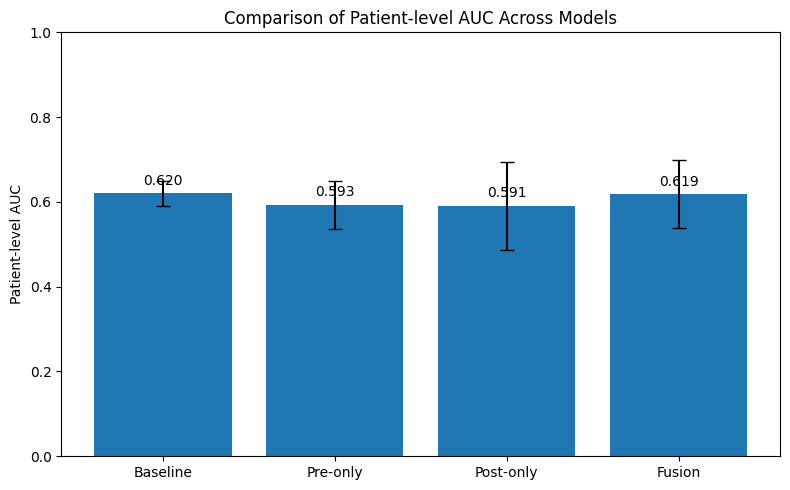

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Baseline", "Pre-only", "Post-only", "Fusion"]
auc_means = [0.6202, 0.5931, 0.5908, 0.6186]
auc_sds = [0.0288, 0.0567, 0.1032, 0.0799]

plt.figure(figsize=(8, 5))
plt.bar(models, auc_means, yerr=auc_sds, capsize=5)
plt.ylabel("Patient-level AUC")
plt.title("Comparison of Patient-level AUC Across Models")
plt.ylim(0.0, 1.0)

for i, v in enumerate(auc_means):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig("patient_auc_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

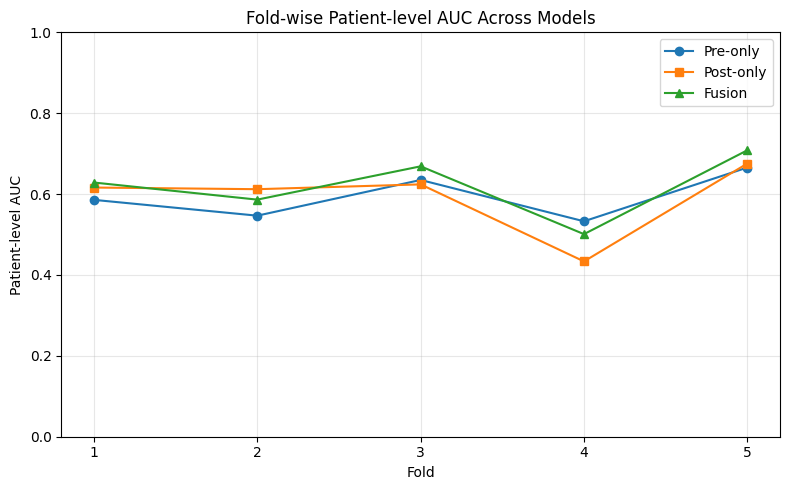

In [ ]:
import matplotlib.pyplot as plt

folds = [1, 2, 3, 4, 5]

pre_auc = [0.585714, 0.546627, 0.634921, 0.532738, 0.665675]
post_auc = [0.616190, 0.612103, 0.624008, 0.433532, 0.675595]
fusion_auc = [0.628571, 0.586310, 0.668651, 0.500992, 0.708333]

plt.figure(figsize=(8, 5))
plt.plot(folds, pre_auc, marker="o", label="Pre-only")
plt.plot(folds, post_auc, marker="s", label="Post-only")
plt.plot(folds, fusion_auc, marker="^", label="Fusion")

plt.xlabel("Fold")
plt.ylabel("Patient-level AUC")
plt.title("Fold-wise Patient-level AUC Across Models")
plt.xticks(folds)
plt.ylim(0.0, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("foldwise_patient_auc.png", dpi=300, bbox_inches="tight")
plt.show()